# How AI Learns From Examples
### A hands-on demo: teaching a computer to read handwritten digits

By the end of this notebook, you will have:
- Seen what a computer actually "sees" when it looks at a digit
- Trained a neural network from scratch
- Drawn your own digits and tested them against the trained model

---

## ⚙️ Setup
Run this first. It installs what we need and loads the libraries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras
import gradio as gr
import shap

print("✅ Ready!")

E:\Tools\Anaconda3\envs\machine_learning_demo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Ready!


---
## 🖼️ Act 1: What Does a Computer Actually See?

The **MNIST dataset** contains 70,000 handwritten digits (0–9), each as a 28×28 pixel image.  
These were collected from US Census Bureau employees and high school students.

But a computer doesn't "see" an image the way you do. Let's look at what's really there.

In [3]:
# Load the dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training images: {x_train.shape}")
print(f"  → {x_train.shape[0]} images, each {x_train.shape[1]}×{x_train.shape[2]} pixels")
print(f"Test images:     {x_test.shape[0]}")

Training images: (60000, 28, 28)
  → 60000 images, each 28×28 pixels
Test images:     10000


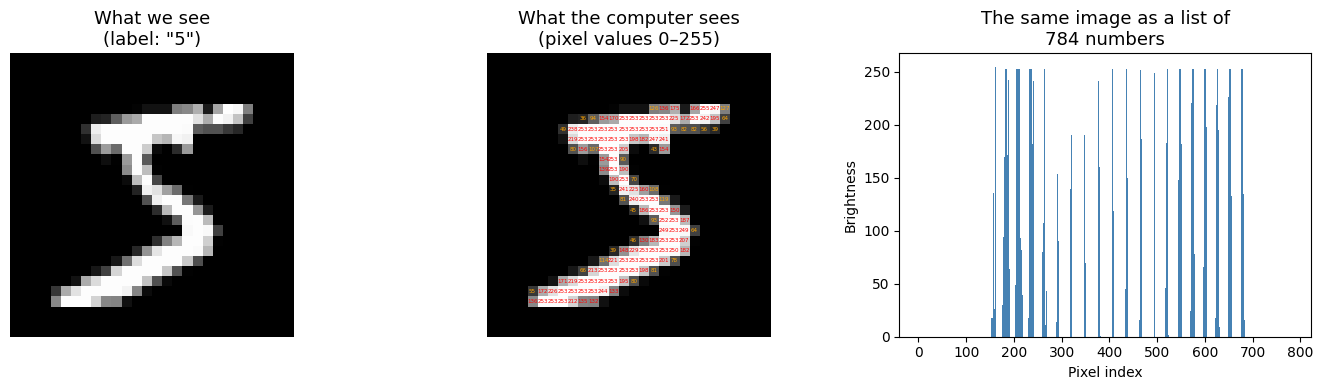


The raw data for this image (first 50 values):
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [4]:
# Pick any digit to inspect (change this number!)
INDEX = 0

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Left: what we see
axes[0].imshow(x_train[INDEX], cmap='gray')
axes[0].set_title(f'What we see\n(label: "{y_train[INDEX]}")', fontsize=13)
axes[0].axis('off')

# Middle: the pixel grid
axes[1].imshow(x_train[INDEX], cmap='gray')
for i in range(28):
    for j in range(28):
        val = x_train[INDEX][i, j]
        if val > 30:
            axes[1].text(j, i, str(val), ha='center', va='center',
                         fontsize=4, color='red' if val > 127 else 'orange')
axes[1].set_title('What the computer sees\n(pixel values 0–255)', fontsize=13)
axes[1].axis('off')

# Right: the flat array (what gets fed into the model)
flat = x_train[INDEX].flatten()
axes[2].bar(range(len(flat)), flat, color='steelblue', width=1.0)
axes[2].set_title(f'The same image as a list of\n{len(flat)} numbers', fontsize=13)
axes[2].set_xlabel('Pixel index')
axes[2].set_ylabel('Brightness')

plt.tight_layout()
plt.show()

print(f"\nThe raw data for this image (first 50 values):")
print(flat[:50])

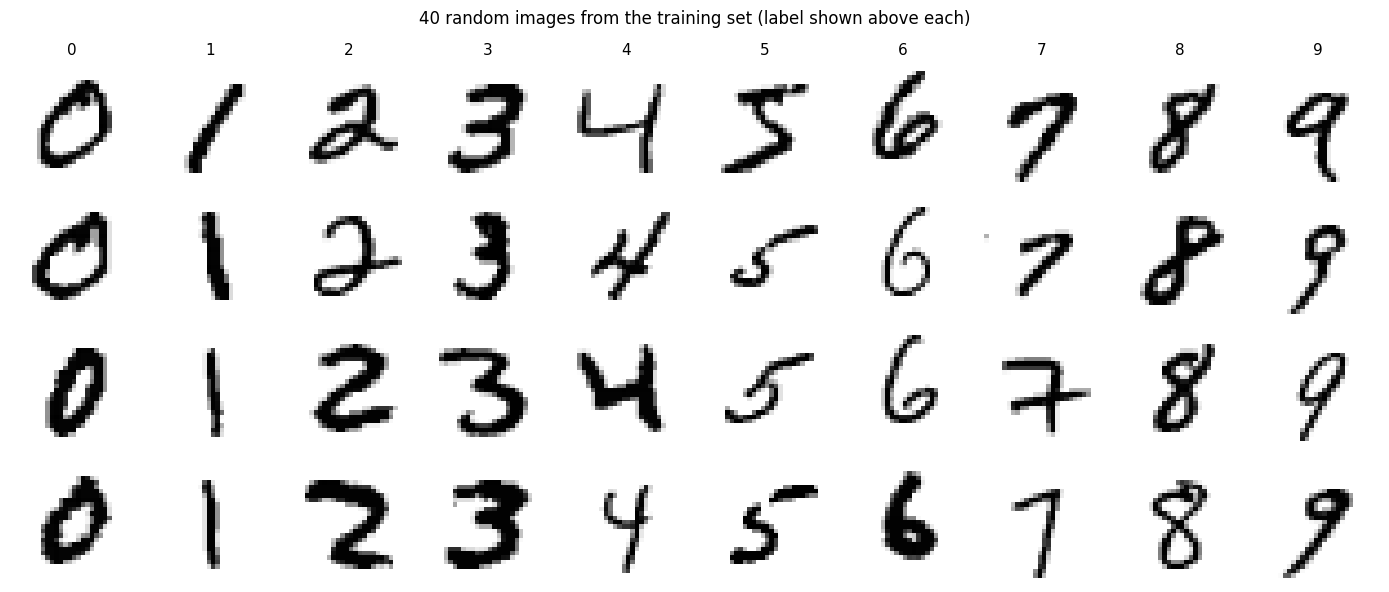

Notice: the same digit looks very different depending on who wrote it.
The model has to learn what's essential — not memorize exact pixel patterns.


In [5]:
# Show a sample of the dataset — all classes
fig, axes = plt.subplots(4, 10, figsize=(14, 6))
fig.suptitle('40 random images from the training set (label shown above each)', fontsize=12)

shown = {i: 0 for i in range(10)}
indices_by_class = {i: np.where(y_train == i)[0] for i in range(10)}

for row in range(4):
    for col in range(10):
        digit = col
        idx = indices_by_class[digit][row]
        axes[row, col].imshow(255-x_train[idx], cmap='gray')
        if row == 0:
            axes[row, col].set_title(str(digit), fontsize=11)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print("Notice: the same digit looks very different depending on who wrote it.")
print("The model has to learn what's essential — not memorize exact pixel patterns.")

In [6]:
#x_train[0]

---
## 🧠 Act 2: Building and Training the Model

A neural network is a stack of layers. Each layer transforms the data a little.  
The network starts with **random weights** — it knows nothing.  
Training is the process of adjusting those weights until predictions improve.

### The key idea: gradient descent

Imagine you're blindfolded on a hilly landscape and want to find the lowest point.  
Your strategy: feel the slope under your feet, take one step downhill. Repeat.

That's exactly what the optimizer does — but in a space with **millions of dimensions**.

In [6]:
underfit_model = keras.Sequential([
    # Flatten: turn 28×28 grid into a list of 784 numbers
    keras.layers.Flatten(input_shape=(28, 28)),

    # Dropout: randomly silence 20% of neurons during training
    # This PREVENTS overfitting (memorizing instead of learning)
    keras.layers.Dropout(0.2),

    keras.layers.Dense(4, activation='relu'),  # only 4 neurons

    # Output layer: 10 neurons, one per digit class
    # Softmax turns raw scores into probabilities that sum to 1
    keras.layers.Dense(10, activation='softmax')
], name="digit_classifier")

underfit_model.summary()

E:\Tools\Anaconda3\envs\machine_learning_demo\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "digit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4)                   │           3,140 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │              50 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,190 (12.46 KB)

 Trainable params: 3,190 (12.46 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Build the model
overfit_model = keras.Sequential([
    # Flatten: turn 28×28 grid into a list of 784 numbers
    keras.layers.Flatten(input_shape=(28, 28)),

    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(512, activation='relu'),

    # Output layer: 10 neurons, one per digit class
    # Softmax turns raw scores into probabilities that sum to 1
    keras.layers.Dense(10, activation='softmax')
], name="digit_classifier")

overfit_model.summary()

Model: "digit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 932,362 (3.56 MB)

 Trainable params: 932,362 (3.56 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Normalize pixel values from 0–255 to 0–1
# (Smaller numbers = easier math for the optimizer)
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

# Build the model
normal_model = keras.Sequential([
    # Flatten: turn 28×28 grid into a list of 784 numbers
    keras.layers.Flatten(input_shape=(28, 28)),

    # Hidden layer: 128 "neurons", each connected to all 784 inputs
    # ReLU activation: "fire if positive, stay silent if negative"
    keras.layers.Dense(128, activation='relu'),

    # Dropout: randomly silence 20% of neurons during training
    # This PREVENTS overfitting (memorizing instead of learning)
    keras.layers.Dropout(0.2),

    # Output layer: 10 neurons, one per digit class
    # Softmax turns raw scores into probabilities that sum to 1
    keras.layers.Dense(10, activation='softmax')
], name="digit_classifier")

normal_model.summary()

Model: "digit_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Compile: choose optimizer, loss function, and what to measure
normal_model.compile(
    optimizer='adam',         # A smart variant of gradient descent
    loss='sparse_categorical_crossentropy',  # Measures how wrong the prediction is
    metrics=['accuracy']
)

underfit_model.compile(
    optimizer='adam',         # A smart variant of gradient descent
    loss='sparse_categorical_crossentropy',  # Measures how wrong the prediction is
    metrics=['accuracy']
)

overfit_model.compile(
    optimizer='adam',         # A smart variant of gradient descent
    loss='sparse_categorical_crossentropy',  # Measures how wrong the prediction is
    metrics=['accuracy']
)

# Test before any training — should be ~10% (random chance for 10 classes)
_, acc_before = normal_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Accuracy BEFORE training: {acc_before:.1%}  (random guessing = 10%)")

Accuracy BEFORE training: 7.7%  (random guessing = 10%)


In [10]:
# Train!
# Each "epoch" = one full pass through all 60,000 training images
history = normal_model.fit(
    x_train_norm, y_train,
    epochs=40,
    batch_size=256,           # Process 256 images at a time, then update weights
    validation_split=0.1,     # Hold out 10% to monitor overfitting
    verbose=1
)

Epoch 1/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8502 - loss: 0.5195 - val_accuracy: 0.9465 - val_loss: 0.2029
Epoch 2/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9295 - loss: 0.2427 - val_accuracy: 0.9595 - val_loss: 0.1490
Epoch 3/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9452 - loss: 0.1893 - val_accuracy: 0.9663 - val_loss: 0.1220
Epoch 4/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9545 - loss: 0.1574 - val_accuracy: 0.9693 - val_loss: 0.1062
Epoch 5/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9600 - loss: 0.1346 - val_accuracy: 0.9723 - val_loss: 0.0950
Epoch 6/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9650 - loss: 0.1187 - val_accuracy: 0.9742 - val_loss: 0.0874
Epoch 7/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9687 - loss: 0.1054 - val_accuracy: 0.9762 - val_loss: 0.0816
Epoch 8/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9720 - loss: 0.0947 - val_accuracy: 0.

In [11]:
# Train!
# Each "epoch" = one full pass through all 60,000 training images
history_overfit = overfit_model.fit(
    x_train_norm[:500], y_train[:500],
    epochs=40,
    batch_size=256,           # Process 256 images at a time, then update weights
    validation_split=0.1,     # Hold out 10% to monitor overfitting
    verbose=1
)

Epoch 1/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - accuracy: 0.2689 - loss: 2.2038 - val_accuracy: 0.6200 - val_loss: 1.8408
Epoch 2/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.7489 - loss: 1.5980 - val_accuracy: 0.7000 - val_loss: 1.3422
Epoch 3/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.8267 - loss: 0.9908 - val_accuracy: 0.8400 - val_loss: 0.8949
Epoch 4/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.8800 - loss: 0.5496 - val_accuracy: 0.8200 - val_loss: 0.7632
Epoch 5/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 0.9022 - loss: 0.3409 - val_accuracy: 0.8600 - val_loss: 0.7073
Epoch 6/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9244 - loss: 0.2463 - val_accuracy: 0.8400 - val_loss: 0.8513
Epoch 7/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9467 - loss: 0.1790 - val_accuracy: 0.8000 - val_loss: 0.9024
Epoch 8/40
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.9600 - loss: 0.1318 - val_accuracy: 0.8400 - val_loss: 0.9591

In [12]:
# Train!
# Each "epoch" = one full pass through all 60,000 training images
history_underfit = underfit_model.fit(
    x_train_norm, y_train,
    epochs=40,
    batch_size=256,           # Process 256 images at a time, then update weights
    validation_split=0.1,     # Hold out 10% to monitor overfitting
    verbose=1
)

Epoch 1/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3416 - loss: 1.7135 - val_accuracy: 0.6175 - val_loss: 1.2053
Epoch 2/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6696 - loss: 1.0547 - val_accuracy: 0.7823 - val_loss: 0.7789
Epoch 3/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7507 - loss: 0.8316 - val_accuracy: 0.8272 - val_loss: 0.6397
Epoch 4/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7805 - loss: 0.7407 - val_accuracy: 0.8457 - val_loss: 0.5706
Epoch 5/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7950 - loss: 0.6880 - val_accuracy: 0.8557 - val_loss: 0.5303
Epoch 6/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8038 - loss: 0.6569 - val_accuracy: 0.8617 - val_loss: 0.5058
Epoch 7/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8107 - loss: 0.6328 - val_accuracy: 0.8632 - val_loss: 0.4865
Epoch 8/40
211/211 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8158 - loss: 0.6162 - val_accuracy: 0.

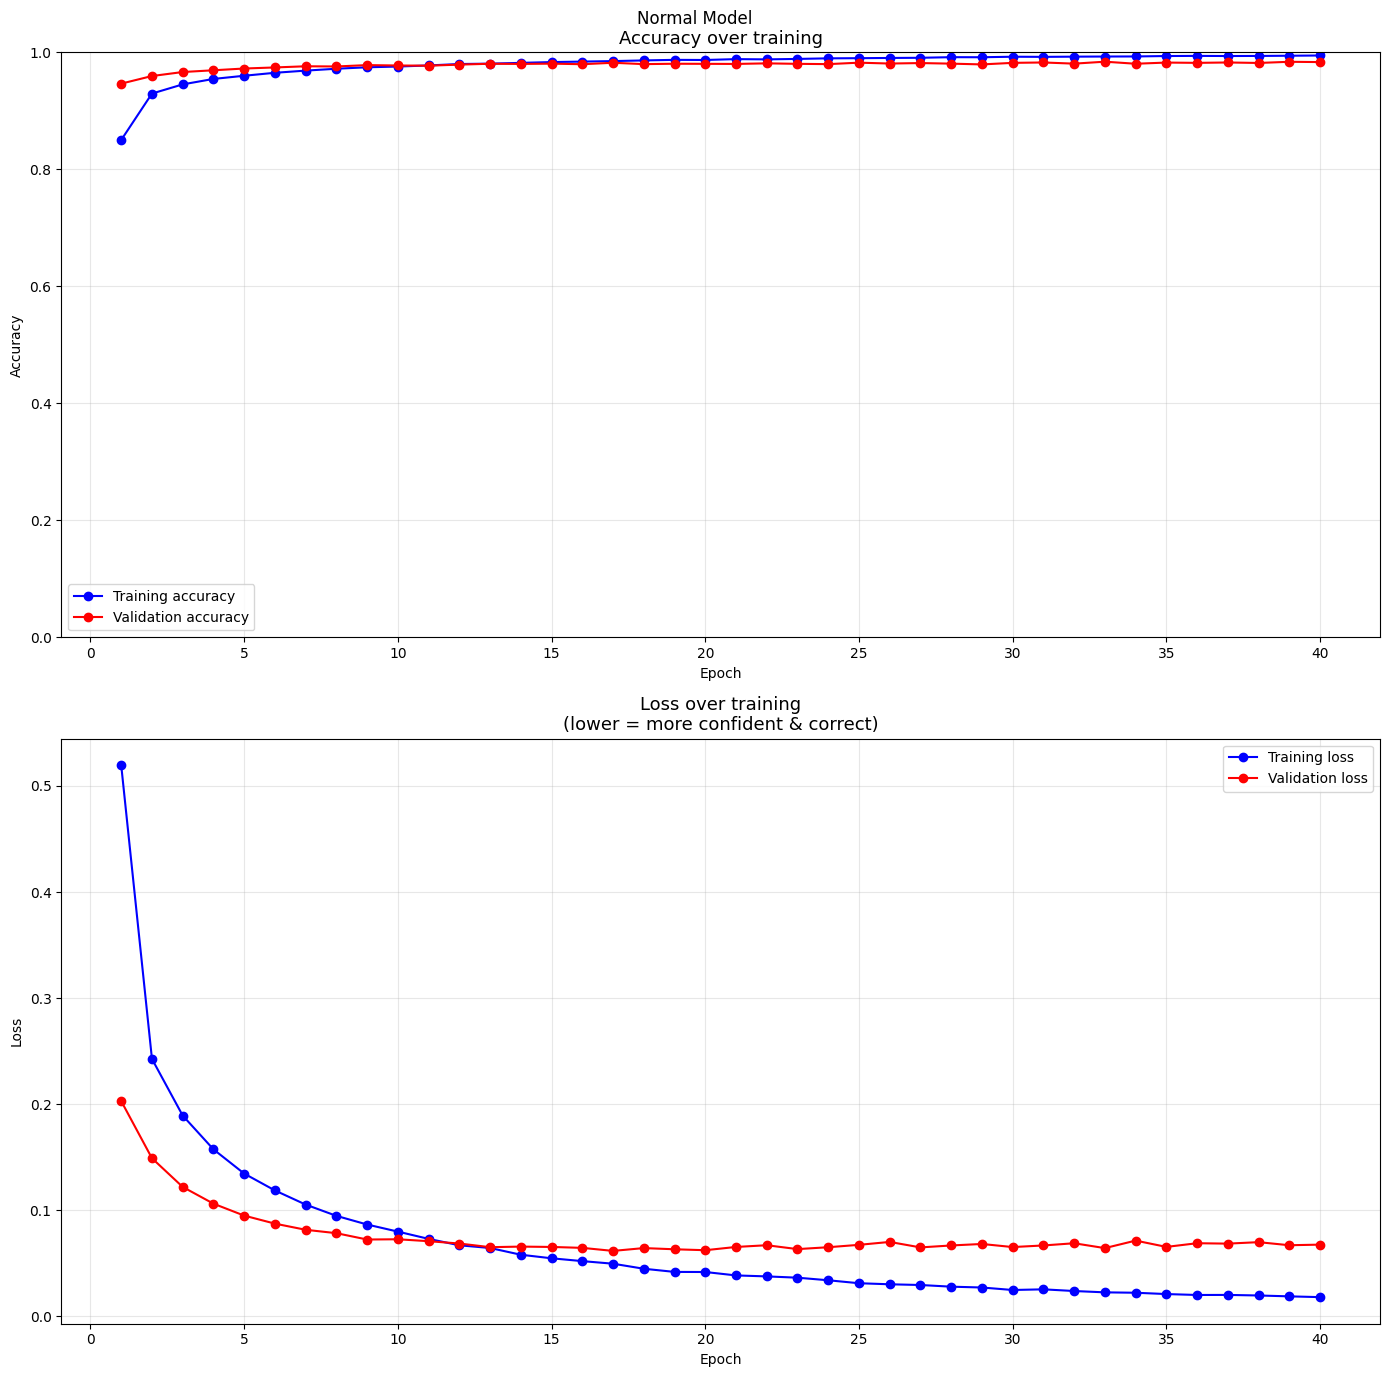


Final accuracy on TEST set (never seen during training): 98.2%


In [13]:
# Plot the learning curves
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

fig.suptitle("Normal Model")

epochs = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs, history.history['accuracy'],     'b-o', label='Training accuracy')
ax1.plot(epochs, history.history['val_accuracy'], 'r-o', label='Validation accuracy')
ax1.set_title('Accuracy over training', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2.plot(epochs, history.history['loss'],     'b-o', label='Training loss')
ax2.plot(epochs, history.history['val_loss'], 'r-o', label='Validation loss')
ax2.set_title('Loss over training\n(lower = more confident & correct)', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

_, acc_after = normal_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nFinal accuracy on TEST set (never seen during training): {acc_after:.1%}")

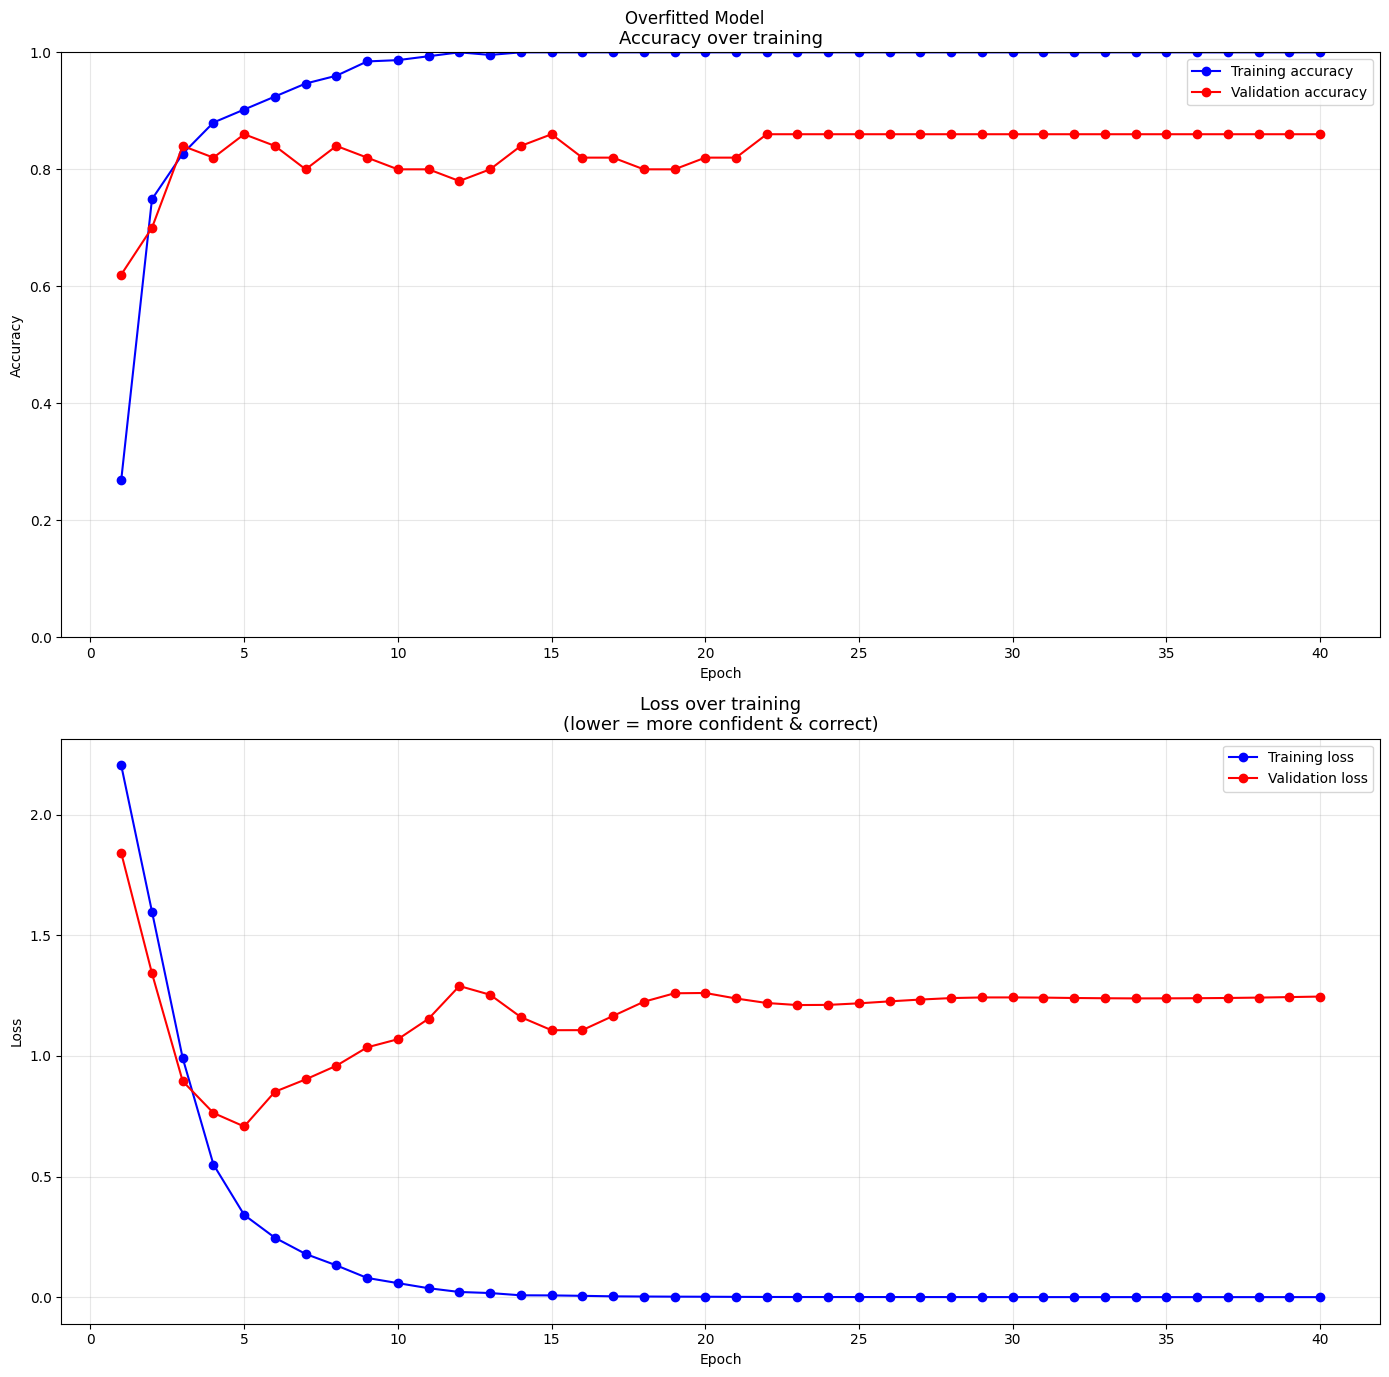


Final accuracy on TEST set (never seen during training): 98.2%


In [14]:
# Plot the learning curves
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

fig.suptitle("Overfitted Model")

epochs = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs, history_overfit.history['accuracy'],     'b-o', label='Training accuracy')
ax1.plot(epochs, history_overfit.history['val_accuracy'], 'r-o', label='Validation accuracy')
ax1.set_title('Accuracy over training', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2.plot(epochs, history_overfit.history['loss'],     'b-o', label='Training loss')
ax2.plot(epochs, history_overfit.history['val_loss'], 'r-o', label='Validation loss')
ax2.set_title('Loss over training\n(lower = more confident & correct)', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

_, acc_after = normal_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nFinal accuracy on TEST set (never seen during training): {acc_after:.1%}")

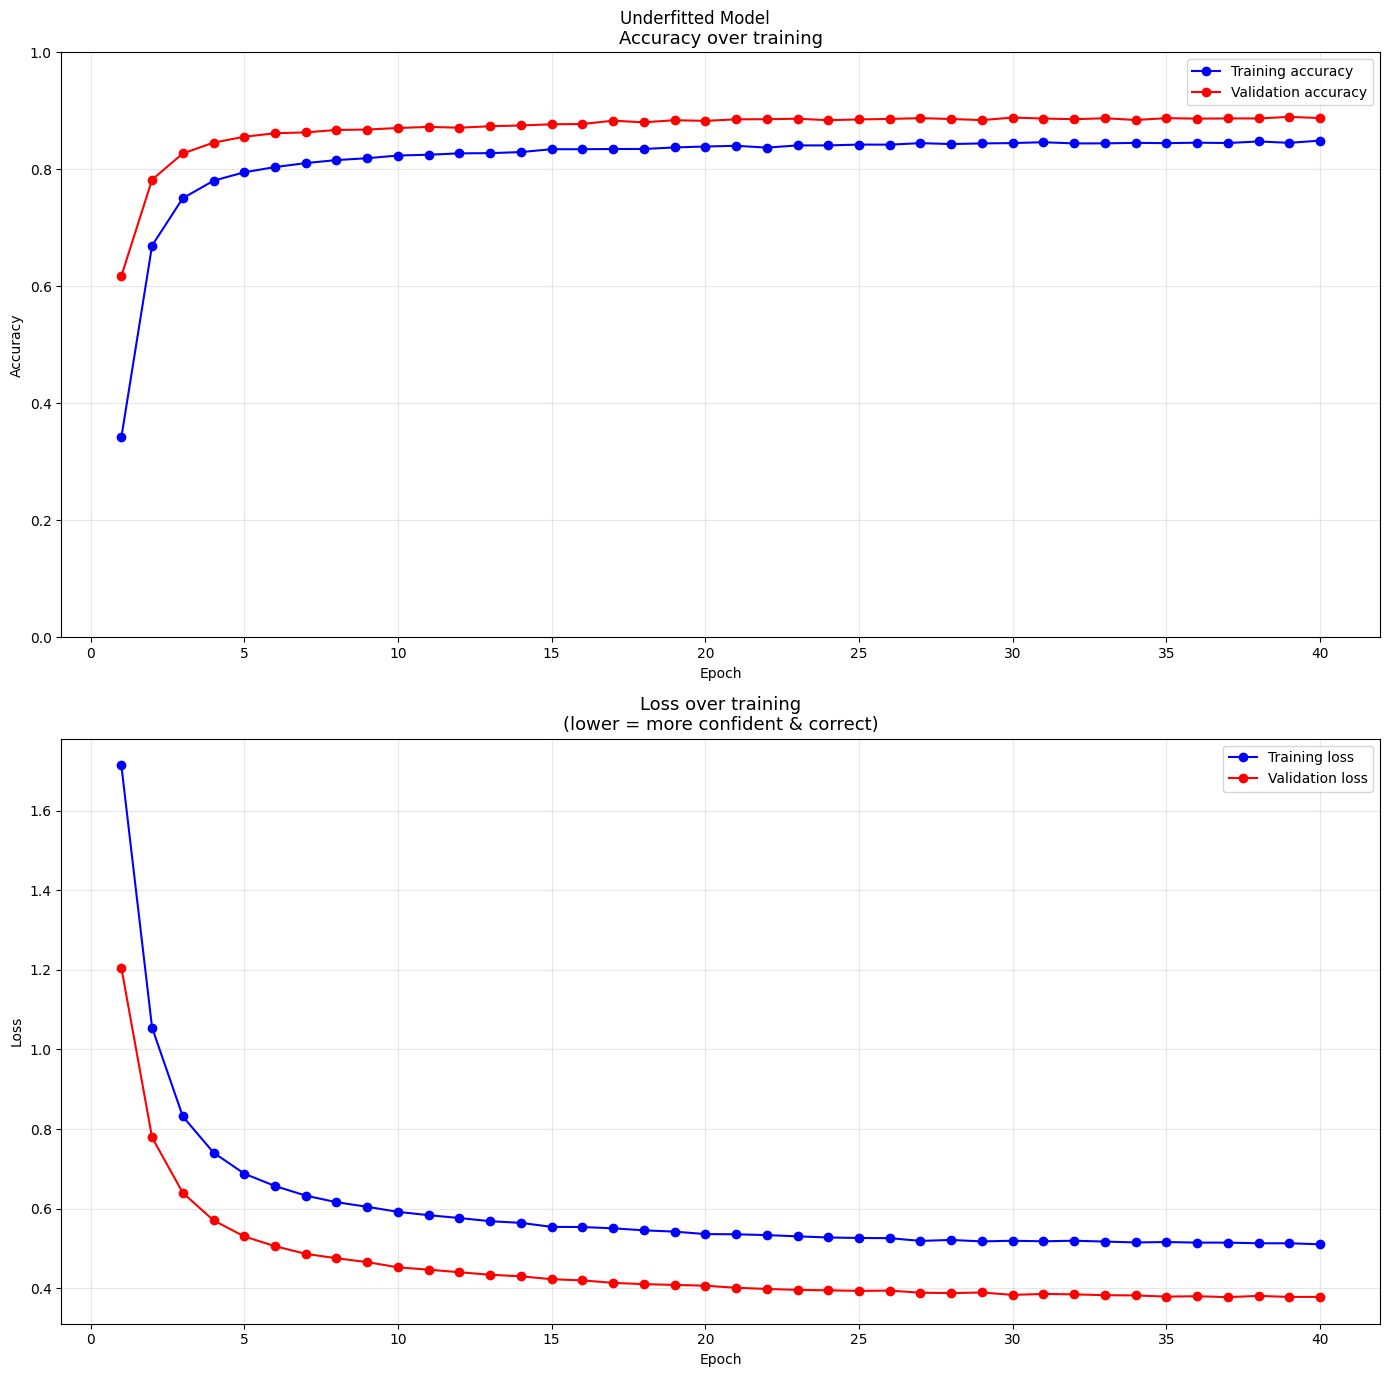


Final accuracy on TEST set (never seen during training): 98.2%


In [15]:
# Plot the learning curves
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 14))

fig.suptitle("Underfitted Model")

epochs = range(1, len(history.history['accuracy']) + 1)

ax1.plot(epochs, history_underfit.history['accuracy'],     'b-o', label='Training accuracy')
ax1.plot(epochs, history_underfit.history['val_accuracy'], 'r-o', label='Validation accuracy')
ax1.set_title('Accuracy over training', fontsize=13)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

ax2.plot(epochs, history_underfit.history['loss'],     'b-o', label='Training loss')
ax2.plot(epochs, history_underfit.history['val_loss'], 'r-o', label='Validation loss')
ax2.set_title('Loss over training\n(lower = more confident & correct)', fontsize=13)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

_, acc_after = normal_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"\nFinal accuracy on TEST set (never seen during training): {acc_after:.1%}")

---
## ⚠️ Act 3: When Things Go Wrong

A ~98% accuracy sounds great. But what does the other 2% look like?

### Key failure modes:
- **Underfitting**: model is too simple, never really learned the patterns
- **Overfitting**: model memorized the training data, fails on new examples
- **Confusion between similar classes**: 3 vs 8, 4 vs 9, 1 vs 7

Total mistakes on test set: 183 out of 10000


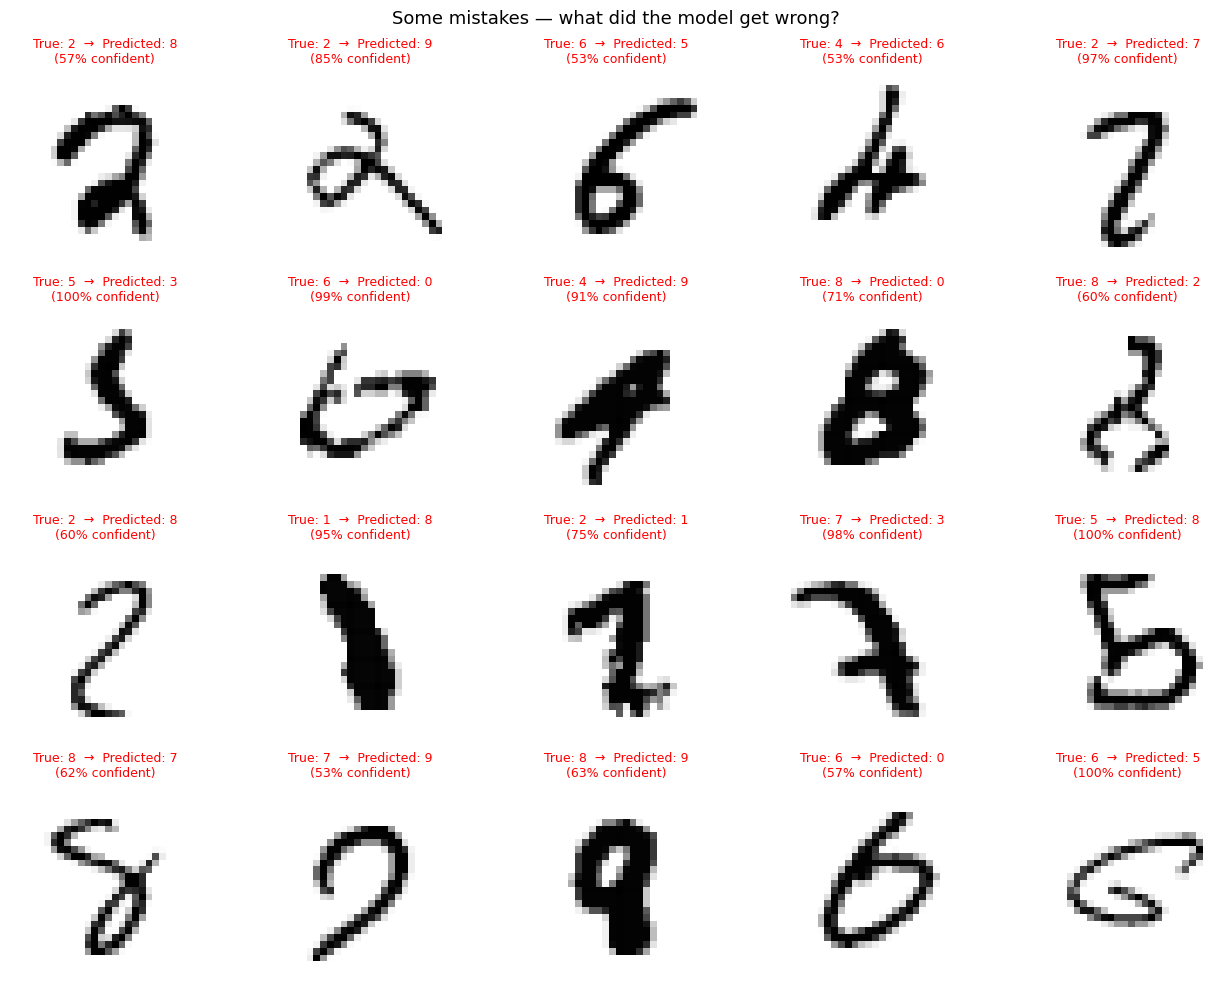

In [18]:
# Show mistakes the model makes
predictions = normal_model.predict(x_test_norm, verbose=0)
pred_labels = np.argmax(predictions, axis=1)

wrong_indices = np.where(pred_labels != y_test)[0]
print(f"Total mistakes on test set: {len(wrong_indices)} out of {len(y_test)}")

# Show 20 mistakes
fig, axes = plt.subplots(4, 5, figsize=(13, 10))
fig.suptitle('Some mistakes — what did the model get wrong?', fontsize=13)

for ax, idx in zip(axes.flat, wrong_indices[:20]):
    ax.imshow(255-x_test[idx], cmap='gray')
    confidence = predictions[idx][pred_labels[idx]]
    ax.set_title(
        f'True: {y_test[idx]}  →  Predicted: {pred_labels[idx]}\n({confidence:.0%} confident)',
        fontsize=9,
        color='red'
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

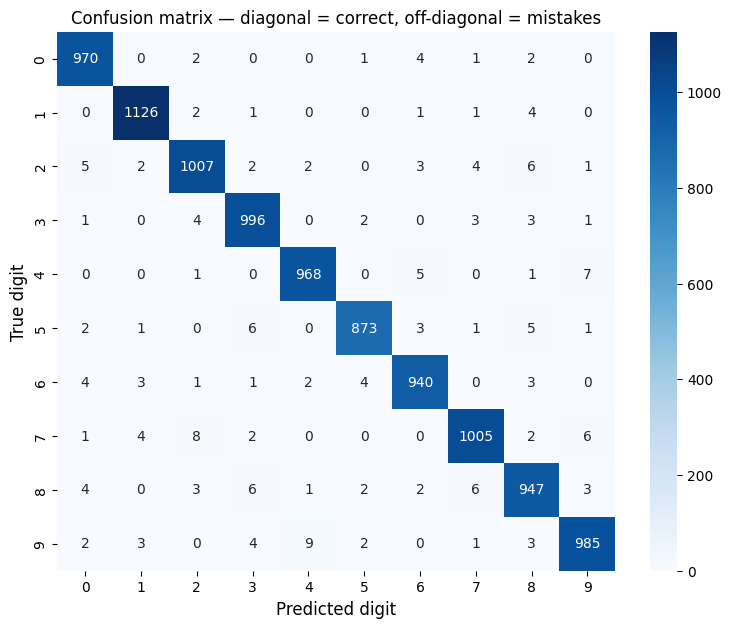

Which pairs are confused most often?
  True 9 → predicted 4: 9 times
  True 7 → predicted 2: 8 times
  True 4 → predicted 9: 7 times
  True 2 → predicted 8: 6 times
  True 5 → predicted 3: 6 times


In [19]:
# Confusion matrix — which digits get mixed up most?
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, pred_labels)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=range(10), yticklabels=range(10))
ax.set_xlabel('Predicted digit', fontsize=12)
ax.set_ylabel('True digit', fontsize=12)
ax.set_title('Confusion matrix — diagonal = correct, off-diagonal = mistakes', fontsize=12)
plt.show()

print("Which pairs are confused most often?")
np.fill_diagonal(cm, 0)
for _ in range(5):
    i, j = np.unravel_index(cm.argmax(), cm.shape)
    print(f"  True {i} → predicted {j}: {cm[i,j]} times")
    cm[i, j] = 0

In [20]:
_, acc = normal_model.evaluate(x_test_norm, y_test, verbose=0)
print(f"Test accuracy: {acc:.1%}")

Test accuracy: 98.2%


In [21]:
# Background dataset: a small sample the explainer uses as a baseline
# "how much does this pixel matter compared to a typical input?"
model = normal_model
background = x_train_norm[:10000]  # 200 random training images as reference

explainer = shap.GradientExplainer(model, background)

---
## ✏️ Act 4: Draw Your Own Digit!

Now you can test the model yourself — draw a digit in the box and see what the model thinks.

The model was trained on a specific style of handwriting. Does it generalize to yours?

In [23]:
import matplotlib.pyplot as plt

X_SIZE_DRAW = 280
Y_SIZE_DRAW = 280
X_SIZE = 28
Y_SIZE = 28

x_test_separated = list()
x_train_separated = list()

def get_saliency(img_norm, class_idx):
    img_tensor = tf.Variable(img_norm[np.newaxis, :, :], dtype=tf.float32)  # shape (1, 28, 28)
    with tf.GradientTape() as tape:
        pred = model(img_tensor, training=False)  # model flattens internally
        score = pred[0, class_idx]
    grads = tape.gradient(score, img_tensor)
    saliency = tf.abs(grads)[0, :, :].numpy()  # shape (28, 28)
    return saliency

with gr.Blocks(title="Digit Recognizer") as demo:
    gr.Markdown("## 🔢 Digit Recognizer")
    
    with gr.Column():
        sketchpad = gr.Sketchpad(
            label="Draw a digit (0–9) here",
            type="numpy",
            canvas_size=(X_SIZE_DRAW, Y_SIZE_DRAW),
        )
        output = gr.Label(num_top_classes=3, label="Model's best guesses")
        with gr.Row():
            submit_btn = gr.Button("Submit", variant="primary")
            clear_btn = gr.Button("Clear")
        gr.Markdown("#### Random test sample")
        with gr.Row():
            replace_btn = list()
            for i in range(10):
                replace_btn.append(gr.Button(f"{i}", scale=1))
                x_test_separated.append(x_test[y_test==i])
        gr.Markdown("#### Random training sample")
        with gr.Row():
            replace_trn_btn = list()
            for i in range(10):
                replace_trn_btn.append(gr.Button(f"{i}", scale=1))
                x_train_separated.append(x_train[y_train==i])
        debug_img = gr.Image(label="What the model sees (28×28)", width=112, height=112)
        shap_plot = gr.Plot(label="SHAP")
    
    def predict_digit(drawing):
        if isinstance(drawing, dict):
            img = drawing.get("composite")
        else:
            img = drawing

        if img is None:
            return {str(i): 0.0 for i in range(10)}, None

        img_gray = 255.0 - img[:, :, 0].astype(np.float32)
        img_resized = tf.image.resize(img_gray[..., np.newaxis], (28, 28))[:, :, 0]
        img_norm = img_resized.numpy() / 255.0
        #print(f"min: {img_norm.min():.3f}, max: {img_norm.max():.3f}, mean: {img_norm.mean():.3f}")

        # Show what model receives
        debug = (img_norm * 255).astype(np.uint8)

        pred = model(img_norm[np.newaxis, :, :], training=False).numpy()[0]

        # Saliency for the predicted class
        predicted = int(np.argmax(pred))
        # saliency = get_saliency(img_norm, predicted)

        # SHAP values: one array per output class, each shaped (1, 28, 28)
        shap_values = explainer.shap_values(img_norm[np.newaxis, :, :])
        
        # Plot input + saliency side by side
        fig, axes = plt.subplots(2, 6, figsize=(10, 5))
        axes[0,0].imshow(img_norm, cmap='gray', vmin=0, vmax=1)
        axes[0,0].set_title('Input', fontsize=9)
        axes[0,0].axis('off')
        max_cmap = np.max(np.abs(shap_values))
        min_cmap = -max_cmap
        for i in range(10):
            sv = shap_values[0,:,:, i]  # shape (28, 28) for predicted class
            y = (i+1)//6
            x = (i+1) % 6
            axes[y,x].imshow(sv, cmap='bwr', vmin=min_cmap, vmax=max_cmap)
            axes[y, x].set_title(f'What drove "{i}"', fontsize=9)
            axes[y, x].axis('off')
        axes[1, 5].axis('off')
        plt.tight_layout()

        return {str(i): float(pred[i]) for i in range(10)}, debug, fig
    
    def clear_fn():
        blank = np.ones((X_SIZE_DRAW, Y_SIZE_DRAW, 4), dtype=np.uint8) * 255
        return blank, None, None

    def replace_fn(digit: int, use_train: bool):
        # Take random test sample
        cur_ds = x_train_separated[digit] if use_train else x_test_separated[digit]
        sample_num = np.random.randint(len(cur_ds))
        # Make 280x280 out of 28x28
        orig_image = np.zeros((X_SIZE, Y_SIZE, 3), dtype=np.uint8)
        for i in range(3):
            orig_image[:,:,i] = cur_ds[sample_num]
        
        tf_im = tf.image.resize(orig_image, (X_SIZE_DRAW, Y_SIZE_DRAW))
        res = np.ones((X_SIZE_DRAW, Y_SIZE_DRAW, 4), dtype=np.uint8)*255
        for i in range(3):
            res[:,:,i] = 255-tf_im[:,:,0]
        return res, None, None
    

    outputs = [output, debug_img, shap_plot]

    submit_btn.click(fn=predict_digit, inputs=sketchpad, outputs=outputs)
    clear_btn.click(fn=clear_fn, outputs=[sketchpad, output, debug_img])
    for i in range(10):
        replace_btn[i].click(fn=lambda digit=i: replace_fn(digit=digit, use_train=False), outputs=[sketchpad, output, debug_img])
    for i in range(10):
        replace_trn_btn[i].click(fn=lambda digit=i: replace_fn(digit=digit, use_train=True), outputs=[sketchpad, output, debug_img])

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860

Could not create share link. Missing file: C:\Users\andre\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\andre\.cache\huggingface\gradio\frpc


E:\Tools\Anaconda3\envs\machine_learning_demo\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_11
Received: inputs=['Tensor(shape=(1, 28, 28))']
  warnings.warn(msg)
E:\Tools\Anaconda3\envs\machine_learning_demo\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_11
Received: inputs=['Tensor(shape=(50, 28, 28))']
  warnings.warn(msg)
E:\Tools\Anaconda3\envs\machine_learning_demo\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_11
Received: inputs=['Tensor(shape=(1, 28, 28))']
  warnings.warn(msg)


In [24]:
gr.close_all()

Closing server running on port: 7860


---
## 💡 Bonus: What Makes This Hard (and Interesting)?

Some questions worth discussing:

1. **Distribution shift**: This model was trained on one style of digit. What happens if you draw in a very different style? Or use digits from a different country's handwriting conventions?

2. **More data vs. smarter model**: The full MNIST has 60,000 examples. What if we used only 1,000? Try `x_train_norm[:1000]` in the training cell and re-run.

3. **Deeper network**: What if we add more layers? More neurons? Does that always help?

4. **The same principle everywhere**: Face recognition, spam filters, voice assistants, medical diagnosis — all of them are doing some version of the same thing you just built.

In [1]:
# OPTIONAL EXPERIMENT: Train with less data and see what happens
# Uncomment and run to compare

# N = 1000  # Try 500, 1000, 5000, 10000
# small_model = keras.models.clone_model(model)
# small_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# small_model.fit(x_train_norm[:N], y_train[:N], epochs=10, validation_split=0.1, verbose=1)
# _, acc = small_model.evaluate(x_test_norm, y_test, verbose=0)
# print(f"Accuracy with {N} training examples: {acc:.1%}")

In [66]:
x_test[y_test==0]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

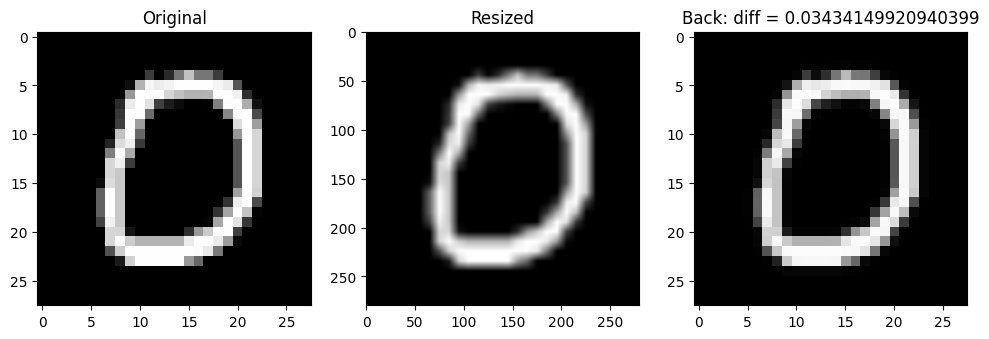

In [120]:
sample_num = 10
#x_test[sample_num]

orig_image = np.zeros((X_SIZE, Y_SIZE, 3), dtype=np.uint8)
for i in range(3):
    orig_image[:,:,i] = x_test[sample_num]

tf_im = tf.image.resize(orig_image/255, (X_SIZE_DRAW, Y_SIZE_DRAW))
un_tf_resized = tf.image.resize(tf_im, (X_SIZE, Y_SIZE))

man_res = np.zeros((X_SIZE_DRAW, Y_SIZE_DRAW, 3), dtype=np.uint8)
#for i in range(X_SIZE_DRAW):
#    for j in range(Y_SIZE_DRAW):
#        for k in range(3)

f, ax = plt.subplots(1,3)
f.set_size_inches(12,6)
ax[0].set_title("Original")
ax[0].imshow(x_test[sample_num], cmap='gray')
ax[1].set_title("Resized")
ax[1].imshow(tf_im, cmap='gray')
ax[2].set_title(f"Back: diff = {np.max(np.abs(orig_image/255-un_tf_resized))}")
ax[2].imshow(un_tf_resized, cmap='gray')
#ax[1,0].imshow(x_test[sample_num], cmap='gray')
#ax[1,1].imshow(man_res, cmap='gray')
#ax[1,2].imshow(un_man_resized, cmap='gray')
plt.show(f)
plt.close(f)

In [101]:
np.array([x_test[sample_num], x_test[sample_num], x_test[sample_num]]).T.shape

(28, 28, 3)